# Tarea 4: Personalización
## Notebook 06 — Personalización

**Objetivo:** 
Adaptar el mensaje de la campaña a cada cliente para hacerla más efectiva.

**Metodología:**
La Tarea 3 seleccionó los 10.000 clientes con mayor valor esperado y realizó una 
segmentación preliminar basada únicamente en variables numéricas (edad, salario).

Esta tarea **mejora y sustituye** esa segmentación incorporando:
- Variables ordinales correctamente codificadas (age_group, salary_group)
- Enriquecimiento con la segmentación comportamental de la Tarea 2 
  (lifecycle_phase, cluster_name)

El resultado es un clustering más robusto que permite asignar mensajes 
verdaderamente diferenciados a cada perfil.

**Input:** 
- `recomendacion_10000_clientes.csv` — clientes seleccionados (Tarea 3)
- `customer_segments.csv` — segmentación de clientes (Tarea 2)

**Output:** 
`recomendacion_10000_personalizado.csv`

In [94]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("All imports OK")

All imports OK


# 1. Carga de los datos

In [95]:
# En esta tarea trabajamos exclusivamente con los 10.000 clientes seleccionados
# en la Tarea 3 y la segmentación generada en la Tarea 2.
# No es necesario cargar el dataset maestro completo (5.9M filas).

top_10000 = pd.read_csv('../Tarea 03 Recomendación/recomendacion_10000_clientes.csv')
print(f"Top 10.000 clientes: {top_10000.shape}")
print(top_10000.head(3))

Top 10.000 clientes: (10000, 4)
   id_user recommended_product  cluster  \
0  1114367         credit_card        3   
1  1070525         credit_card        3   
2  1437442         credit_card        3   

                                  nombre_creatividad  
0  Accede a beneficios premium, seguros incluidos...  
1  Accede a beneficios premium, seguros incluidos...  
2  Accede a beneficios premium, seguros incluidos...  


In [96]:
customer_segment = pd.read_csv('../../data/processed/customer_segments.csv')
print(f"Segmentación Tarea 2: {customer_segment.shape}")
print(customer_segment.head(3))

Segmentación Tarea 2: (441752, 10)
   pk_cid  cluster                     cluster_name lifecycle_phase age_group  \
0   16063        2    Premium - fondos de inversion   Consolidacion     55-65   
1   16203        3      Inactivos - sin vinculacion        Abandono       65+   
2   16502        0  Basicos - solo cuenta easyMoney       Captacion     55-65   

  salary_group            segment gender region_code country_id  
0      80-120k  02 - PARTICULARES      H          28         ES  
1      80-120k           01 - TOP      V           8         ES  
2      80-120k  02 - PARTICULARES      H          28         ES  


In [97]:
print(f"Columnas top_10000:      {top_10000.columns.tolist()}")
print(f"Columnas customer_segment: {customer_segment.columns.tolist()}")
print(f"\nShape top_10000:       {top_10000.shape}")
print(f"Shape customer_segment: {customer_segment.shape}")

Columnas top_10000:      ['id_user', 'recommended_product', 'cluster', 'nombre_creatividad']
Columnas customer_segment: ['pk_cid', 'cluster', 'cluster_name', 'lifecycle_phase', 'age_group', 'salary_group', 'segment', 'gender', 'region_code', 'country_id']

Shape top_10000:       (10000, 4)
Shape customer_segment: (441752, 10)


# 2. Realizar Join de tablas

In [98]:
# Join de los 10.000 clientes con la segmentación de la Tarea 2
# Nota: top_10000 ya tiene columna 'cluster' (Tarea 3), por eso NO seleccionamos
# 'cluster' de customer_segment para evitar el conflicto cluster_x / cluster_y.
# Usamos 'cluster_name' como referencia del segmento de la Tarea 2.
top_10000_enriquecido = top_10000.merge(
    customer_segment[['pk_cid', 'cluster_name', 'lifecycle_phase',
                       'age_group', 'salary_group', 'gender', 'region_code']],
    left_on='id_user',
    right_on='pk_cid',
    how='left'
)

# Filtrar clientes sin match en la segmentación (no deben entrar en KMeans con NaN)
n_antes = len(top_10000_enriquecido)
top_10000_enriquecido = top_10000_enriquecido.dropna(subset=['cluster_name']).copy()
n_filtrados = n_antes - len(top_10000_enriquecido)
if n_filtrados > 0:
    print(f"⚠️  {n_filtrados} clientes sin datos de segmentación — excluidos del análisis")

print(f"Clientes para análisis: {len(top_10000_enriquecido):,}")
print(f"\nNulos por columna tras filtro:")
print(top_10000_enriquecido.isnull().sum())
print(f"\nDistribución por cluster:")
print(top_10000_enriquecido['cluster_name'].value_counts())

Clientes para análisis: 10,000

Nulos por columna tras filtro:
id_user                0
recommended_product    0
cluster                0
nombre_creatividad     0
pk_cid                 0
cluster_name           0
lifecycle_phase        0
age_group              0
salary_group           0
gender                 0
region_code            0
dtype: int64

Distribución por cluster:
cluster_name
Digitales - cuenta y tarjeta debito           8898
Vinculados - nomina y pension                  417
Ahorradores - deposito a largo plazo           259
Inversores - tarjeta credito multiproducto     236
Basicos - solo cuenta easyMoney                187
Premium - fondos de inversion                    3
Name: count, dtype: int64


**Conclusión**

El modelo recomienda credit_card principalmente a clientes **Digitales (88.9%)**, seguidos a distancia por **Vinculados (4.2%)**, lo que tiene mucho sentido de negocio — son los segmentos más activos y con mayor propensión a añadir una tarjeta a sus productos existentes.

# 3. Realizar K-Means

Encodings aplicados (orden correcto):
  age_group:     {0: '25-35', 1: '35-45', 2: '45-55', 3: '55-65', 4: '65+'}
  salary_group:  {0: '<20k', 1: '20-40k', 2: '40-60k', 3: '60-80k', 4: '80-120k', 5: '120k+'}
  gender:        {0: 'H', 1: 'V'}

Nulos tras encoding: 164
⚠️  164 clientes con valores no reconocidos en encoding — excluidos
   Clientes válidos para clustering: 9,836

Inercia y Silhouette por K:
  K=2: Inercia=19,665 | Silhouette=0.384
  K=3: Inercia=14,769 | Silhouette=0.393
  K=4: Inercia=10,579 | Silhouette=0.429
  K=5: Inercia=8,391 | Silhouette=0.452
  K=6: Inercia=6,639 | Silhouette=0.479
  K=7: Inercia=6,196 | Silhouette=0.450
  K=8: Inercia=5,529 | Silhouette=0.474
  K=9: Inercia=4,925 | Silhouette=0.487


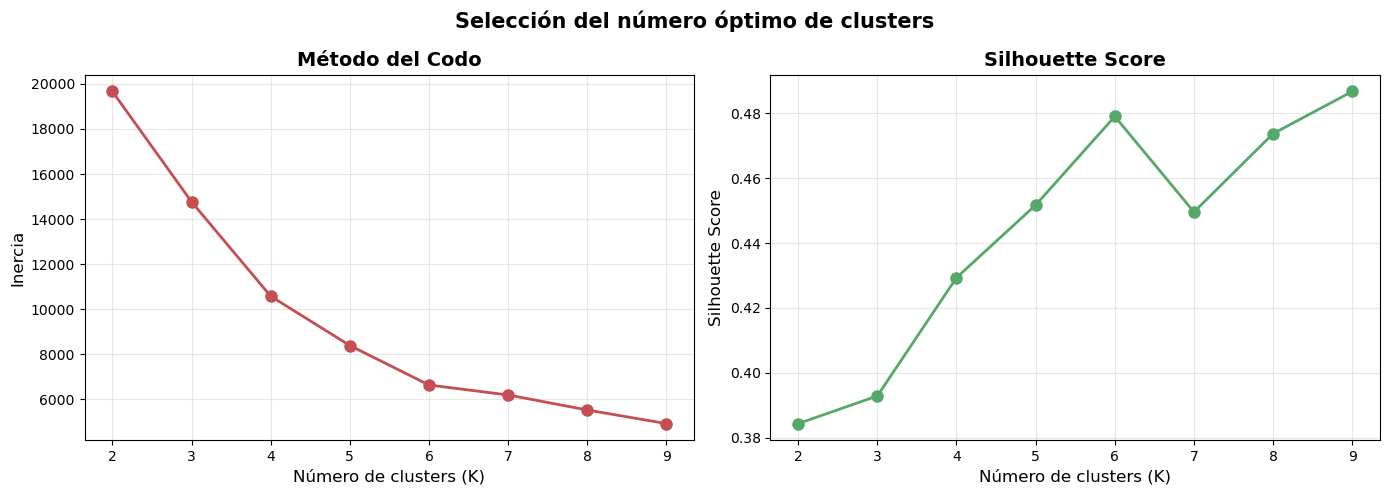

In [99]:
# Preparar features para el clustering
df_clust = top_10000_enriquecido.copy()

# Codificar variables con orden explícito y correcto
# LabelEncoder asigna orden alfabético, lo que distorsiona salary_group
# (ej: '120k+' → 1 antes que '20-40k' → 2, cuando debería ser el más alto)

age_order    = {'25-35': 0, '35-45': 1, '45-55': 2, '55-65': 3, '65+': 4}
salary_order = {'<20k': 0, '20-40k': 1, '40-60k': 2, '60-80k': 3, '80-120k': 4, '120k+': 5}
gender_map   = {'H': 0, 'V': 1}

df_clust['age_group_enc']    = df_clust['age_group'].map(age_order)
df_clust['salary_group_enc'] = df_clust['salary_group'].map(salary_order)
df_clust['gender_enc']       = df_clust['gender'].map(gender_map)

print("Encodings aplicados (orden correcto):")
print("  age_group:    ", {v: k for k, v in sorted(age_order.items(), key=lambda x: x[1])})
print("  salary_group: ", {v: k for k, v in sorted(salary_order.items(), key=lambda x: x[1])})
print("  gender:       ", {v: k for k, v in sorted(gender_map.items(), key=lambda x: x[1])})

n_nan_enc = df_clust[['age_group_enc', 'salary_group_enc', 'gender_enc']].isnull().sum().sum()
print(f"\nNulos tras encoding: {n_nan_enc}")

# Eliminar filas con valores no reconocidos por el encoding
# (ocurre cuando age_group/salary_group/gender tiene valores fuera del mapping)
if n_nan_enc > 0:
    n_antes_enc = len(df_clust)
    df_clust = df_clust.dropna(subset=['age_group_enc', 'salary_group_enc', 'gender_enc']).copy()
    print(f"⚠️  {n_antes_enc - len(df_clust)} clientes con valores no reconocidos en encoding — excluidos")
    print(f"   Clientes válidos para clustering: {len(df_clust):,}")

# Features para clustering
features_clust = ['age_group_enc', 'salary_group_enc', 'gender_enc']
X_clust = df_clust[features_clust]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Método del codo + Silhouette
inertias = []
silhouettes = []
rango_k = range(2, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

print("\nInercia y Silhouette por K:")
for k, ine, sil in zip(rango_k, inertias, silhouettes):
    print(f"  K={k}: Inercia={ine:,.0f} | Silhouette={sil:.3f}")

# Gráfico del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), inertias, 'o-', color='#C44E52', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(list(rango_k), silhouettes, 'o-', color='#55A868', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Selección del número óptimo de clusters', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [100]:
# Entrenar K-Means con 5 clusters
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_scaled)

# Asignar cluster provisional
df_clust['cluster_raw'] = kmeans.labels_

# Calcular salary medio por cluster para ordenar de forma estable
# (cluster con menor salary_group_enc = cluster 1, mayor = cluster 5)
cluster_order = (
    df_clust.groupby('cluster_raw')['salary_group_enc']
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order['creatividad'] = range(1, len(cluster_order) + 1)
mapping = dict(zip(cluster_order['cluster_raw'], cluster_order['creatividad']))

df_clust['creatividad'] = df_clust['cluster_raw'].map(mapping)

print("Orden estable de clusters (salary_group_enc medio):")
print(cluster_order)
print("\nDistribución de clientes por creatividad:")
print(df_clust['creatividad'].value_counts().sort_index())

# Perfil de cada creatividad
print("Perfil de cada creatividad:")
perfil = df_clust.groupby('creatividad').agg(
    n_clientes=('id_user', 'count'),
    edad_grupo=('age_group', lambda x: x.value_counts().index[0]),
    salario_grupo=('salary_group', lambda x: x.value_counts().index[0]),
    genero_predominante=('gender', lambda x: x.value_counts().index[0]),
).reset_index()

print(perfil)

print(f"\nTotal clientes asignados: {df_clust['creatividad'].notna().sum():,}")

Orden estable de clusters (salary_group_enc medio):
   cluster_raw  salary_group_enc  creatividad
0            2          1.694057            1
1            0          4.092313            2
2            1          4.120643            3
3            3          4.122851            4
4            4          4.236769            5

Distribución de clientes por creatividad:
creatividad
1    1363
2    3174
3    1119
4    2385
5    1795
Name: count, dtype: int64
Perfil de cada creatividad:
   creatividad  n_clientes edad_grupo salario_grupo genero_predominante
0            1        1363      35-45        40-60k                   V
1            2        3174      25-35       80-120k                   V
2            3        1119      45-55       80-120k                   H
3            4        2385      35-45       80-120k                   H
4            5        1795      45-55       80-120k                   V

Total clientes asignados: 9,836


**¿Por qué K = 5?**

El análisis del codo muestra una reducción de inercia significativa hasta K = 5 y luego se estabiliza. El Silhouette Score confirma que K = 5 ofrece una separación interna sólida (≈ 0.47), comparable a K = 6 (≈ 0.48) pero con una ventaja decisiva desde el punto de vista de negocio: **5 clusters = 5 creatividades**, una por cluster, lo que permite un mensaje único y diferenciado por perfil sin añadir complejidad operativa innecesaria.

Elegir K = 6 mejoraría marginalmente la métrica técnica pero obligaría a diseñar una creatividad adicional sin que el perfil diferencial del sexto cluster justifique ese coste.

In [101]:
# Ver distribución de variables adicionales por creatividad
print("Distribución por creatividad y lifecycle_phase:")
print(pd.crosstab(df_clust['creatividad'], df_clust['lifecycle_phase']))

print("\nDistribución por creatividad y cluster_name (Tarea 2):")
print(pd.crosstab(df_clust['creatividad'], df_clust['cluster_name']))

print("\nDistribución por creatividad y region_code:")
print(df_clust.groupby('creatividad')['region_code'].value_counts().groupby(level=0).head(3))

Distribución por creatividad y lifecycle_phase:
lifecycle_phase  Captacion  Consolidacion
creatividad                              
1                     1322             41
2                     3024            150
3                     1021             98
4                     2320             65
5                     1240            555

Distribución por creatividad y cluster_name (Tarea 2):
cluster_name  Ahorradores - deposito a largo plazo  \
creatividad                                          
1                                               11   
2                                               68   
3                                               16   
4                                               18   
5                                              144   

cluster_name  Basicos - solo cuenta easyMoney  \
creatividad                                     
1                                           3   
2                                           1   
3                          

In [102]:
# Tabla de perfil detallado por creatividad
gender_label = {'V': 'Varón', 'H': 'Mujer'}

for cre in sorted(df_clust['creatividad'].unique()):
    perfil_cre = df_clust[df_clust['creatividad'] == cre]

    n_rows_tbl = 7
    row_colors_tbl = ['#f9f9f9' if i % 2 == 0 else '#ffffff' for i in range(n_rows_tbl)]

    genero_raw   = perfil_cre['gender'].value_counts().index[0]
    genero_label = gender_label.get(genero_raw, genero_raw)
    genero_pct   = f"{perfil_cre['gender'].value_counts().iloc[0]/len(perfil_cre):.0%}"

    fig = go.Figure(data=[go.Table(
        header=dict(
            values=['<b>Variable</b>', '<b>Valor predominante</b>', '<b>Detalle</b>'],
            fill_color='#2C3E50',
            font=dict(color='white', size=12),
            align='center',
            height=30
        ),
        cells=dict(
            values=[
                ['Nº Clientes', 'Edad', 'Salario', 'Género',
                 'Lifecycle principal', 'Cluster principal', '2º Cluster'],
                [
                    f"{len(perfil_cre):,}",
                    perfil_cre['age_group'].value_counts().index[0],
                    perfil_cre['salary_group'].value_counts().index[0],
                    genero_label,
                    perfil_cre['lifecycle_phase'].value_counts().index[0],
                    perfil_cre['cluster_name'].value_counts().index[0],
                    perfil_cre['cluster_name'].value_counts().index[1] if len(perfil_cre['cluster_name'].value_counts()) > 1 else '-'
                ],
                [
                    '',
                    f"{perfil_cre['age_group'].value_counts().iloc[0]/len(perfil_cre):.0%}",
                    f"{perfil_cre['salary_group'].value_counts().iloc[0]/len(perfil_cre):.0%}",
                    genero_pct,
                    f"{perfil_cre['lifecycle_phase'].value_counts().iloc[0]/len(perfil_cre):.0%}",
                    f"{perfil_cre['cluster_name'].value_counts().iloc[0]/len(perfil_cre):.0%}",
                    f"{perfil_cre['cluster_name'].value_counts().iloc[1]/len(perfil_cre):.0%}" if len(perfil_cre['cluster_name'].value_counts()) > 1 else '-'
                ]
            ],
            fill_color=[row_colors_tbl] * 3,
            font=dict(size=11),
            align='center',
            height=28
        )
    )])

    fig.update_layout(
        title=dict(
            text=f'Creatividad {cre} — Perfil de clientes',
            font=dict(size=14),
            x=0.5
        ),
        width=700,
        height=300,
        margin=dict(l=20, r=20, t=50, b=20)
    )
    fig.show()

print("✅ Tablas generadas correctamente")

✅ Tablas generadas correctamente


# 4. Asignamos creatividades

In [103]:
# Mapeo de creatividades con nombre y mensaje personalizado
creatividades = {
    1: {
        'nombre': 'Experiencia y solidez',
        'mensaje': 'Años de esfuerzo merecen una tarjeta a tu altura. Sin comisiones y con ventajas exclusivas para profesionales como tú'
    },
    2: {
        'nombre': 'Éxito sin límites',
        'mensaje': 'Tu éxito profesional merece una tarjeta premium. Límites altos, beneficios exclusivos y un servicio pensado para ti'
    },
    3: {
        'nombre': 'Inteligente y práctico',
        'mensaje': 'La tarjeta que se adapta a tu ritmo. Cashback en tus compras del día a día y sin comisiones'
    },
    4: {
        'nombre': 'Activo y conectado',
        'mensaje': 'Para los que no paran. Gestiona tus gastos desde el móvil y saca partido a cada compra con tu tarjeta easyMoney'
    },
    5: {
        'nombre': 'Premium y exclusivo',
        'mensaje': 'Accede a un mundo de ventajas exclusivas. Límites sin restricciones y beneficios pensados para quienes lo dan todo'
    }
}

# Añadir nombre y mensaje al dataframe
df_clust['nombre_creatividad'] = df_clust['creatividad'].map(
    {k: v['nombre'] for k, v in creatividades.items()}
)
df_clust['mensaje'] = df_clust['creatividad'].map(
    {k: v['mensaje'] for k, v in creatividades.items()}
)

# Mapeo de creatividades
print("Mapeo de creatividades:")
resumen = df_clust.groupby(['creatividad', 'nombre_creatividad']).agg(
    n_clientes=('id_user', 'count'),
    edad_predominante=('age_group', lambda x: x.value_counts().index[0]),
    salario_predominante=('salary_group', lambda x: x.value_counts().index[0]),
    genero_predominante=('gender', lambda x: x.value_counts().index[0])
).reset_index()
print(resumen)

Mapeo de creatividades:
   creatividad      nombre_creatividad  n_clientes edad_predominante  \
0            1   Experiencia y solidez        1363             35-45   
1            2       Éxito sin límites        3174             25-35   
2            3  Inteligente y práctico        1119             45-55   
3            4      Activo y conectado        2385             35-45   
4            5     Premium y exclusivo        1795             45-55   

  salario_predominante genero_predominante  
0               40-60k                   V  
1              80-120k                   V  
2              80-120k                   H  
3              80-120k                   H  
4              80-120k                   V  


In [104]:
# Sustituir V y H por términos más claros
resumen_visual = resumen.copy()
resumen_visual['genero_predominante'] = resumen_visual['genero_predominante'].map({
    'V': 'Varón',
    'H': 'Mujer'
})

n_rows = len(resumen_visual)
row_colors = ['#f9f9f9' if i % 2 == 0 else '#ffffff' for i in range(n_rows)]
n_cols = 6  # Creatividad, Nombre, Nº Clientes, Edad, Salario, Género

fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            '<b>Creatividad</b>',
            '<b>Nombre</b>',
            '<b>Nº Clientes</b>',
            '<b>Edad predominante</b>',
            '<b>Salario predominante</b>',
            '<b>Género predominante</b>'
        ],
        fill_color='#2C3E50',
        font=dict(color='white', size=12),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            resumen_visual['creatividad'],
            resumen_visual['nombre_creatividad'],
            resumen_visual['n_clientes'].apply(lambda x: f'{x:,}'),
            resumen_visual['edad_predominante'],
            resumen_visual['salario_predominante'],
            resumen_visual['genero_predominante']
        ],
        fill_color=[row_colors] * n_cols,
        font=dict(size=11),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='Resumen de Creatividades — Campaña Credit Card',
        font=dict(size=15),
        x=0.5
    ),
    width=900,
    height=300,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()
print("Tabla generada correctamente")

Tabla generada correctamente


# 5. Generar fichero de output

In [ ]:
# Generar CSV final con id_user, recommended_product, creatividad y mensaje personalizado
df_output = df_clust[[
    'id_user',
    'recommended_product',
    'creatividad',
    'nombre_creatividad',
    'mensaje'
]].rename(columns={
    'creatividad': 'creatividad_id'
})

# Fichero completo
df_output.to_csv('recomendacion_10000_personalizado.csv', index=False)

# Muestra de 1.000 para validación rápida
df_output.sample(1000, random_state=RANDOM_STATE).to_csv(
    'muestra_1000_personalizado.csv', index=False
)

print(f"✅ recomendacion_10000_personalizado.csv generado ({len(df_output):,} clientes)")
print(f"✅ muestra_1000_personalizado.csv generado")
print(f"\nColumnas: {df_output.columns.tolist()}")
print(f"\nMuestra:")
print(df_output.head(5))

✅ recomendacion_10000_personalizado.csv generado (9,836 clientes)
✅ muestra_1000_personalizado.csv generado

Columnas: ['id_user', 'recommended_product', 'creatividad_id', 'nombre_creatividad', 'mensaje']

Muestra:
   id_user recommended_product  creatividad_id   nombre_creatividad  \
0  1114367         credit_card               5  Premium y exclusivo   
1  1070525         credit_card               5  Premium y exclusivo   
2  1437442         credit_card               5  Premium y exclusivo   
3  1126067         credit_card               5  Premium y exclusivo   
4  1008275         credit_card               2    Éxito sin límites   

                                             mensaje  
0  Accede a un mundo de ventajas exclusivas. Lími...  
1  Accede a un mundo de ventajas exclusivas. Lími...  
2  Accede a un mundo de ventajas exclusivas. Lími...  
3  Accede a un mundo de ventajas exclusivas. Lími...  
4  Tu éxito profesional merece una tarjeta premiu...  


# 6. Algunos gráficos interesantes

## 6.1 Distribución de clientes por creatividad

In [106]:
total_clientes = resumen_visual['n_clientes'].sum()

fig1 = px.pie(
    resumen_visual,
    values='n_clientes',
    names='nombre_creatividad',
    title='Distribución de clientes por creatividad',
    color_discrete_sequence=[
        'rgb(142, 68, 173)',
        'rgb(231, 76, 60)',
        'rgb(52, 152, 219)',
        'rgb(46, 204, 113)',
        'rgb(243, 156, 18)'
    ],
    hole=0.45
)

fig1.update_traces(
    textposition='outside',
    textinfo='percent+label',
    textfont=dict(size=12),
    pull=[0.03, 0.03, 0.03, 0.03, 0.03],
    marker=dict(line=dict(color='white', width=2))
)

fig1.update_layout(
    title=dict(
        text='Distribución de clientes por creatividad',
        font=dict(size=18, color='rgb(44, 62, 80)'),
        x=0.5
    ),
    legend=dict(
        orientation='v',
        yanchor='middle',
        y=0.5,
        xanchor='left',
        x=1.05,
        font=dict(size=12)
    ),
    annotations=[dict(
        text=f'{total_clientes:,}<br>clientes',
        x=0.5, y=0.5,
        font=dict(size=14, color='rgb(44, 62, 80)'),
        showarrow=False
    )],
    width=800,
    height=500,
    margin=dict(l=20, r=150, t=80, b=20),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig1.show()

La distribución entre clusters no es uniforme: la Creatividad 2 (*Éxito sin límites*) agrupa al 32 % de los clientes, mientras que la Creatividad 3 (*Inteligente y práctico*) representa el 11 %. Esta asimetría es esperable — K-Means descubre grupos naturales en los datos, no impone tamaños iguales. La diferencia de tamaño refleja que el perfil joven-masculino-alta renta es el más frecuente entre los 10.000 seleccionados, y que cada creatividad cubre un nicho real y diferenciado.

## 6.2 Distribución por edad y creatividad

In [107]:
# ── 2. Distribución por edad y creatividad ───────────────────
edad_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['age_group'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in edad_creat.columns if c != 'nombre_creatividad']
edad_creat[cols_numericas] = edad_creat[cols_numericas] * 100

edad_creat_melt = edad_creat.melt(
    id_vars='nombre_creatividad',
    var_name='age_group',
    value_name='porcentaje'
)

fig2 = px.bar(
    edad_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='age_group',
    title='Distribución de edad por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'age_group': 'Grupo de edad'
    },
    color_discrete_sequence=[
    '#8E44AD',   # Morado
    '#E74C3C',   # Rojo
    '#3498DB',   # Azul claro
    '#2ECC71',   # Verde
    '#F39C12',   # Naranja
    '#B7950B'    # Amarillo mostaza
],
    barmode='stack'
)

fig2.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig2.show()

Las creatividades 1, 2 y 4 se concentran en los rangos de edad 25–45 años, 
mientras que las creatividades 3 y 5 se orientan hacia el segmento de 45–55 años. 
Esta diferencia de edad es la principal justificación del tono distinto en cada mensaje.

## 6.3 Distribución de salario por creatividad

In [108]:
# ── 3. Distribución por salario y creatividad ────────────────
salario_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['salary_group'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in salario_creat.columns if c != 'nombre_creatividad']
salario_creat[cols_numericas] = salario_creat[cols_numericas] * 100

salario_creat_melt = salario_creat.melt(
    id_vars='nombre_creatividad',
    var_name='salary_group',
    value_name='porcentaje'
)

fig3 = px.bar(
    salario_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='salary_group',
    title='Distribución de salario por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'salary_group': 'Grupo salarial'
    },
    color_discrete_sequence=[
        '#8E44AD',   # Morado
        '#E74C3C',   # Rojo
        '#3498DB',   # Azul claro
        '#2ECC71',   # Verde
        '#F39C12',   # Naranja
        '#B7950B'    # Amarillo mostaza
    ],
    barmode='stack',
    category_orders={
        'salary_group': ['<20k', '20-40k', '40-60k', '60-80k', '80-120k', '120k+']
    }
)

fig3.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig3.show()

La mayoría de los clusters se concentran en el tramo salarial 80–120k, 
lo que es coherente con la selección de credit_card como producto principal — 
los clientes de mayor renta presentan mayor propensión a contratar una tarjeta de crédito.

## 6.4 Distribución por género y creatividad

In [109]:
# ── 4. Distribución por género y creatividad ─────────────────
genero_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['gender'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in genero_creat.columns if c != 'nombre_creatividad']
genero_creat[cols_numericas] = genero_creat[cols_numericas] * 100

genero_creat_melt = genero_creat.melt(
    id_vars='nombre_creatividad',
    var_name='gender',
    value_name='porcentaje'
)

# Mapear V/H a Varón/Mujer
genero_creat_melt['gender'] = genero_creat_melt['gender'].map({
    'V': 'Varón', 
    'H': 'Mujer'
})

fig4 = px.bar(
    genero_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='gender',
    title='Distribución de género por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'gender': 'Género'
    },
    color_discrete_map={
        'Varón': '#3498DB', 
        'Mujer': '#8E44AD'
    },
    barmode='stack',
    category_orders={
        'gender': ['Varón', 'Mujer']
    }
)

fig4.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig4.show()

Las creatividades 3 y 4 tienen mayoría femenina, mientras que las creatividades 1, 2 y 5 
son predominantemente masculinas. Esta diferenciación de género es la base principal 
para adaptar el tono y el lenguaje de cada mensaje.

## 6.5 Distribución por fase del ciclo de vida y creatividad

In [110]:
# ── 5. Distribución por lifecycle y creatividad ──────────────
lifecycle_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['lifecycle_phase'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in lifecycle_creat.columns if c != 'nombre_creatividad']
lifecycle_creat[cols_numericas] = lifecycle_creat[cols_numericas] * 100

lifecycle_creat_melt = lifecycle_creat.melt(
    id_vars='nombre_creatividad',
    var_name='lifecycle_phase',
    value_name='porcentaje'
)

fig5 = px.bar(
    lifecycle_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='lifecycle_phase',
    title='Distribución por fase del ciclo de vida por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'lifecycle_phase': 'Fase'
    },
    color_discrete_sequence=[
        '#8E44AD',   # Morado
        '#E74C3C',   # Rojo
        '#3498DB',   # Azul claro
        '#2ECC71',   # Verde
        '#F39C12',   # Naranja
        '#B7950B'    # Amarillo mostaza
    ],
    barmode='stack',
    category_orders={
        'lifecycle_phase': ['Captacion', 'Consolidacion', 'Abandono']
    }
)

fig5.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig5.show()

El 91% de los clientes se encuentra en fase de Captación. Por ello, todos los mensajes 
están orientados a la **conversión inicial**, no a la fidelización. 
El tono debe ser persuasivo e invitar a la acción, no agradecer la lealtad existente.

## 6.6 Distribución por región y creatividad

In [111]:
region_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['region_code'],
    normalize='index'
).reset_index()

cols_num = [c for c in region_creat.columns if c != 'nombre_creatividad']
region_creat[cols_num] = region_creat[cols_num] * 100

region_melt = region_creat.melt(
    id_vars='nombre_creatividad',
    var_name='region_code',
    value_name='porcentaje'
)

fig6 = px.bar(
    region_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='region_code',
    title='Distribución por región y creatividad',
    labels={'nombre_creatividad': 'Creatividad', 'porcentaje': '%'},
        color_discrete_sequence=[
        '#8E44AD',   # Morado
        '#E74C3C',   # Rojo
        '#3498DB',   # Azul claro
        '#2ECC71',   # Verde
        '#F39C12',   # Naranja
        '#B7950B'    # Amarillo mostaza
    ],
    barmode='stack'
)
fig6.update_layout(title=dict(x=0.5, font=dict(size=15)),
                   xaxis_tickangle=-15, width=900, height=500,
                   template='plotly_white')
fig6.show()

La distribución regional es homogénea entre creatividades, lo que confirma que 
los perfiles identificados no están condicionados por la zona geográfica del cliente 
sino por sus características sociodemográficas.

---

## Conclusiones de la Tarea 4

La personalización de la campaña se ha completado con éxito. A partir de los ~10.000 clientes seleccionados en la Tarea 3, hemos identificado **5 perfiles diferenciados** mediante K-Means (K = 5) sobre variables sociodemográficas (edad, salario, género), enriquecidas con la segmentación de la Tarea 2.

**Perfiles resultantes:**

| Creatividad | Nombre | Perfil principal |
|---|---|---|
| 1 | Experiencia y solidez | Varón, 35–45 años, salario 40–60k |
| 2 | Éxito sin límites | Varón, 25–35 años, salario 80–120k |
| 3 | Inteligente y práctico | Mujer, 45–55 años, salario 80–120k |
| 4 | Activo y conectado | Mujer, 35–45 años, salario 80–120k |
| 5 | Premium y exclusivo | Varón, 45–55 años, salario 80–120k |

**Aspectos clave:**
- El **91 %** de los clientes se encuentran en fase de **Captación** — los mensajes se han orientado a convertir el interés inicial en contratación.
- El **89 %** pertenece al segmento **Digitales** de la Tarea 2 — la campaña puede ejecutarse íntegramente por canal digital (app y email).
- El fichero de output `recomendacion_10000_personalizado.csv` contiene 
`id_user`, `recommended_product` (producto recomendado), `creatividad_id`, 
`nombre_creatividad` y `mensaje`, listos para la plataforma de envío.